<a href="https://colab.research.google.com/github/Swag-Pseudopy/Escaping-Preference-Collapse/blob/main/generate_animations_nlhf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GIF saved as 'phase_transition.gif'


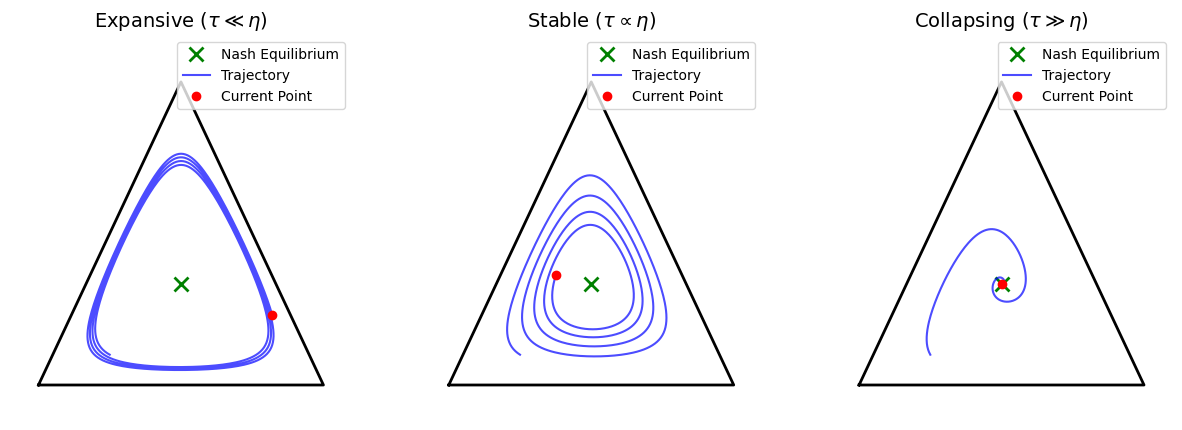

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Function to project 3D simplex points to 2D for plotting
def project_simplex(p):
    x = 0.5 * (2 * p[1] + p[2]) / (p[0] + p[1] + p[2])
    y = (np.sqrt(3) / 2) * p[2] / (p[0] + p[1] + p[2])
    return x, y

# Nash-MD Update Step
def nash_md_update(p, A, eta, tau):
    p_ref = np.array([1/3, 1/3, 1/3])
    log_unnorm = (1 - eta * tau) * np.log(p) + (eta * tau) * np.log(p_ref) + eta * (A @ p)
    log_unnorm -= np.max(log_unnorm)
    p_next = np.exp(log_unnorm)
    return p_next / np.sum(p_next)

# Setup parameters
A = np.array([[0, 1, -1], [-1, 0, 1], [1, -1, 0]])
eta = 0.05
taus = [0.002, 0.025, 0.2]  # Expansive, Stable, Collapsing
titles = [r"Expansive ($\tau \ll \eta$)", r"Stable ($\tau \propto \eta$)", r"Collapsing ($\tau \gg \eta$)"]
p_start = np.array([0.7, 0.2, 0.1])
frames = 1000 # Increased frames for longer animation

# Pre-calculate trajectories
trajectories = [[p_start] for _ in range(3)]
for i, tau in enumerate(taus):
    p = p_start.copy()
    for _ in range(frames):
        p = nash_md_update(p, A, eta, tau)
        trajectories[i].append(p)

# Setup the plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
lines = []
points = []

# Nash Equilibrium point
nash_eq = np.array([1/3, 1/3, 1/3])
nash_eq_2d_x, nash_eq_2d_y = project_simplex(nash_eq)

for ax, title in zip(axes, titles):
    # Draw simplex boundaries
    ax.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], 'k-', lw=2)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.0)
    ax.set_title(title, fontsize=14)
    ax.axis('off')

    # Plot Nash Equilibrium point
    ax.plot(nash_eq_2d_x, nash_eq_2d_y, 'gx', markersize=10, mew=2, label='Nash Equilibrium')

    line, = ax.plot([], [], lw=1.5, alpha=0.7, color='blue', label='Trajectory')
    point, = ax.plot([], [], 'ro', markersize=6, label='Current Point')
    lines.append(line)
    points.append(point)
    ax.legend()

def init():
    for line, point in zip(lines, points):
        line.set_data([], [])
        point.set_data([], [])
    return lines + points

def animate(i):
    for j in range(3):
        # Get history up to frame i
        history = np.array(trajectories[j][:i+1])
        x, y = project_simplex(history.T)

        lines[j].set_data(x, y)
        # Fix: Wrap scalar x[-1] and y[-1] in lists for set_data
        points[j].set_data([x[-1]], [y[-1]])
    return lines + points

# Generate Animation
anim = animation.FuncAnimation(fig, animate, init_func=init, frames=frames, interval=40, blit=True)

# Save as GIF (Requires imagemagick or pillow)
anim.save('phase_transition.gif', writer='pillow', fps=25)
print("GIF saved as 'phase_transition.gif'")